# Modeling exploration

Use this notebook to iterate on feature engineering and model behavior locally without Strava API calls.

## Setup

Run once from repo root:
```bash
pip install -r requirements-dev.txt
python -m ipykernel install --user --name train-tomorrow
```

To use live data, set `USE_LIVE_DATA = True` in the next cell. Requires a repo-root `.env` with `STRAVA_CLIENT_ID`, `STRAVA_CLIENT_SECRET`, `STRAVA_REFRESH_TOKEN`, and optionally `FORECAST_LAT`/`FORECAST_LON`.

In [1]:
import logging
import os
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

sys.path.insert(0, str(Path.cwd().parent / "scripts"))  # allow importing sibling scripts modules

from blurb import generate_blurb, summarize_top_contributors, generate_gemini_prompt, generate_blurb_llm
from features import FEATURE_COLUMNS, prepare_datasets
from model import evaluate_models, feature_contributions, predict_tomorrow, train_and_save_models, walk_forward_evaluate
from strava_client import fetch_activities_dataframe, out_of_range_dates
from weather_client import DEFAULT_LAT, DEFAULT_LON, fetch_historical_weather, fetch_tomorrow_forecast

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s", force=True)
load_dotenv(Path.cwd().parent / ".env")  # repo root .env


True

In [2]:
USE_LIVE_DATA = True  # set True to pull real Strava activities + Open-Meteo forecast via .env secrets

if USE_LIVE_DATA:
    activities = fetch_activities_dataframe(days_back=365*2)
    weather = fetch_tomorrow_forecast()
    activity_dates = pd.to_datetime(activities['date'], errors='coerce').dt.date.dropna()
    historical_weather = (
        fetch_historical_weather(activity_dates.min(), activity_dates.max())
        if not activity_dates.empty
        else None
    )
    if historical_weather is not None:
        home_lat = float(os.getenv('FORECAST_LAT', DEFAULT_LAT))
        home_lon = float(os.getenv('FORECAST_LON', DEFAULT_LON))
        stale_dates = out_of_range_dates(activities, home_lat, home_lon)
        historical_weather = historical_weather.drop(index=list(stale_dates), errors='ignore')

prepared = prepare_datasets(activities=activities, tomorrow_weather=weather, historical_weather=historical_weather)
prepared.historical[['as_of_date', 'target_date'] + FEATURE_COLUMNS + ['will_train_tomorrow']].tail(2)



2026-09-26 11:05:40,760 INFO strava_client: Fetched 737 activities from Strava. Used 4 pages to get 730 days


,as_of_date,target_date,acute_load_7,chronic_load_28,atl_ctl_ratio,days_since_last_hard,streak_length,trained_today,trained_hard_today,trained_days_2,...,forecast_rain_expected,forecast_wind_speed,forecast_temp_high_vs_seasonal,forecast_temp_low_vs_seasonal,forecast_precip_probability_vs_seasonal,forecast_wind_speed_vs_seasonal,forecast_precip_morning,forecast_precip_midday,forecast_precip_evening,will_train_tomorrow
728,2026-09-24,2026-09-25,40.204737,30.222696,1.330283,1,4,1,0,2.0,...,1,29.1,-3.886971,-0.355700,49.117807,17.481433,100.0,71.428571,80.0,1
729,2026-09-25,2026-09-26,36.403553,29.862510,1.219039,2,5,1,0,2.0,...,0,13.1,-2.778176,-2.503583,-22.014115,1.449837,0.0,0.000000,0.0,1


In [12]:
prepared.historical.to_csv("local_data/historical.csv", index=False)


In [4]:
with tempfile.TemporaryDirectory() as tmpdir:
    models = train_and_save_models(prepared.historical, Path(tmpdir))
    prediction = predict_tomorrow(models, prepared.tomorrow_features)
    contributions = feature_contributions(models.classifier, prepared.tomorrow_features)

prediction

2026-09-26 11:05:48,597 INFO model: classifier_accuracy=0.603 (baseline=0.733)
2026-09-26 11:05:48,598 INFO model: classifier_auc=0.673
2026-09-26 11:05:48,598 INFO model: classifier_precision=0.818 recall=0.589 f1=0.685
2026-09-26 11:05:48,599 INFO model: refitting classifier on full dataset (n=730) before saving
2026-09-26 11:05:49,063 INFO model: regressor_mae=34.017
2026-09-26 11:05:49,063 INFO model: refitting regressor on full positive-label dataset (n=380) before saving


{'will_train': False,
 'probability': 0.4597966969013214,
 'predicted_effort': None}

## Model analysis

Confusion matrix / ROC for the classifier, predicted-vs-actual for the regressor, and feature importances — all computed on the same held-out time-based test split used during training.

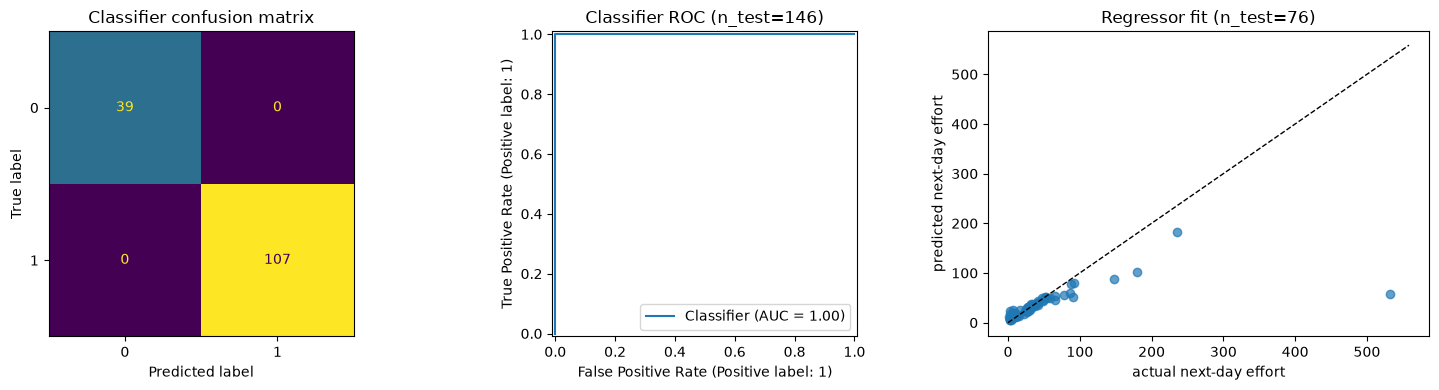

In [5]:
eval_results = evaluate_models(models, prepared.historical)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    eval_results['y_test'], (eval_results['probs'] >= 0.5).astype(int), ax=axes[0], colorbar=False
)
axes[0].set_title('Classifier confusion matrix')

RocCurveDisplay.from_predictions(eval_results['y_test'], eval_results['probs'], ax=axes[1])
axes[1].set_title(f"Classifier ROC (n_test={len(eval_results['y_test'])})")

axes[2].scatter(eval_results['reg_true'], eval_results['reg_pred'], alpha=0.7)
lims = [0, max(eval_results['reg_true'].max(), eval_results['reg_pred'].max(), 1) * 1.05]
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_xlabel('actual next-day effort')
axes[2].set_ylabel('predicted next-day effort')
axes[2].set_title(f"Regressor fit (n_test={len(eval_results['reg_true'])})")

plt.tight_layout()
plt.show()

In [6]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'classifier_importance': models.classifier.feature_importances_,
    'regressor_importance': models.regressor.feature_importances_,
}).sort_values('classifier_importance', ascending=False).reset_index(drop=True)

importance_df

,feature,classifier_importance,regressor_importance
0,trained_days_7,0.108873,0.045001
1,day_of_week,0.062254,0.035150
2,forecast_precip_midday,0.053746,0.062819
3,trained_days_30,0.050011,0.049949
4,forecast_temp_low,0.046040,0.027379
5,dow_train_rate,0.042867,0.035389
6,moving_time_chronic_28,0.035284,0.033580
7,acute_load_7,0.035211,0.027024
8,forecast_temp_high,0.033916,0.022915
9,forecast_precip_probability_vs_seasonal,0.031984,0.037612


In [7]:
folds = walk_forward_evaluate(prepared.historical, n_folds=5)
folds

,fold,n_train,n_test,positive_rate,auc,accuracy,baseline_accuracy
0,0,365,73,0.410959,0.689147,0.602740,0.589041
1,1,438,73,0.602740,0.604232,0.465753,0.602740
2,2,511,73,0.657534,0.541667,0.520548,0.657534
3,3,584,73,0.780822,0.643640,0.589041,0.780822
4,4,657,73,0.684932,0.724348,0.657534,0.684932


In [10]:
top_contributors = summarize_top_contributors(contributions, top_n=11)
blurb = generate_blurb(
    will_train=prediction['will_train'],
    probability=prediction['probability'],
    predicted_effort=prediction['predicted_effort'],
    top_contributors=top_contributors,
)
llm_blurb = generate_blurb_llm(
    will_train=prediction['will_train'],
    probability=prediction['probability'],
    predicted_effort=prediction['predicted_effort'],
    top_contributors=top_contributors,
    fallback_blurb=blurb,
)

pd.DataFrame(top_contributors)
print(blurb)
print(llm_blurb)

2026-09-26 11:07:32,636 INFO google_genai.models: AFC is enabled with max remote calls: 10.
2026-09-26 11:07:32,638 WARNING google_genai.models: Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
2026-09-26 11:07:40,404 INFO httpx: HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent "HTTP/1.1 200 OK"


Probably a recovery day (46% train chance). your usual day-of-week rhythm is dragging more than the daytime temperature forecast can offset.
**Tomorrow’s Verdict: Rest Day 🛋️**
* **Probability to train:** 46% *(so don't pretend you were actually going to)*
* **Predicted effort:** Zero. Zip. Nada.

### **Why you’re staying on the couch:**

* **You’re a creature of habit:** The main reason you’re not training is simply what day of the week it is. Your usual calendar rhythm and your dismal history of actually working out on this specific day are doing all the heavy lifting to keep you off your bike. 
* **Nice weather won't save you:** Sure, the warm forecast and the fact that it’s been a minute since your last long ride are trying to tempt you outside, but your weekly tradition of slacking today is far too powerful. 

Enjoy your couch time!


In [9]:
test_output = {
    "date": str(prepared.tomorrow_features.iloc[0]["target_date"]),
    "will_train": bool(prediction["will_train"]),
    "probability": round(float(prediction["probability"]), 4),
    "predicted_effort": (
        round(float(prediction["predicted_effort"]), 2)
        if prediction["predicted_effort"] is not None
        else None
    ),
    "top_contributors": top_contributors,
    "blurb": blurb,
}